# Counterfactual Modelling

In this tutorial, we demonstrate how to use `normet` to estimate counterfactual
("what would have happened without the intervention") effects with synthetic
control methods.

We will cover:
- Classic synthetic control (`scm`) and its donor weights.
- ML-based synthetic control (`mlscm`) with FLAML and LightGBM backends.
- Placebo-in-space tests and effect bands for inference.
- Uncertainty bands via jackknife and bootstrap.
- Running synthetic control across all units with `scm_all`.

In [1]:
import pandas as pd
import normet as nm
import matplotlib.pyplot as plt
import matplotlib

In [2]:
from normet.utils.logging import enable_default_logging
enable_default_logging(level="WARNING")

In [3]:
from _synth import make_aq_weekly

scm_data = make_aq_weekly()

# Filter to the same date window used in the original notebook
df = scm_data.query("date>='2015-05-01'").query("date<'2016-04-30'")

In [4]:
# Define the treated unit, donor pool, and intervention date
treated_unit = "2+26 cities"
donor_pool = [
    "Dongguan", "Zhongshan", "Foshan", "Beihai", "Nanning", "Nanchang", "Xiamen",
    "Taizhou", "Ningbo", "Guangzhou", "Huizhou", "Hangzhou", "Liuzhou",
    "Shantou", "Jiangmen", "Heyuan", "Quanzhou", "Haikou", "Shenzhen",
    "Wenzhou", "Huzhou", "Zhuhai", "Fuzhou", "Shaoxing", "Zhaoqing",
    "Zhoushan", "Quzhou", "Jinhua", "Shaoguan", "Sanya", "Jieyang",
    "Meizhou", "Shanwei", "Zhanjiang", "Chaozhou", "Maoming", "Yangjiang"
]
df=df[df['ID'].isin(donor_pool+["2+26 cities"])]
cutoff_date = "2015-10-23" # Define the intervention start date

In [5]:
scm_result=nm.scm(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",
                  donors=donor_pool,cutoff_date='2015-10-23')

In [6]:
scm_result

{'synthetic':              observed  synthetic     effect
 date                                       
 2015-05-03  36.822724  36.537563   0.285161
 2015-05-10  35.284317  35.519014  -0.234697
 2015-05-17  34.742172  34.747215  -0.005043
 2015-05-24  34.482513  34.431788   0.050725
 2015-05-31  34.490734  34.585291  -0.094557
 2015-06-07  33.772677  33.695164   0.077513
 2015-06-14  33.150117  33.082645   0.067472
 2015-06-21  31.997821  32.154204  -0.156383
 2015-06-28  30.736631  30.952307  -0.215676
 2015-07-05  30.486214  30.515918  -0.029703
 2015-07-12  30.138826  29.764681   0.374145
 2015-07-19  29.264074  29.231348   0.032727
 2015-07-26  28.563726  28.749502  -0.185776
 2015-08-02  28.612871  28.699026  -0.086155
 2015-08-09  28.836226  28.537991   0.298234
 2015-08-16  28.961804  29.032769  -0.070965
 2015-08-23  29.539887  29.556016  -0.016129
 2015-08-30  29.019531  29.216834  -0.197304
 2015-09-06  29.167830  29.249974  -0.082143
 2015-09-13  29.979261  29.926675   0.0525

<Axes: xlabel='date'>

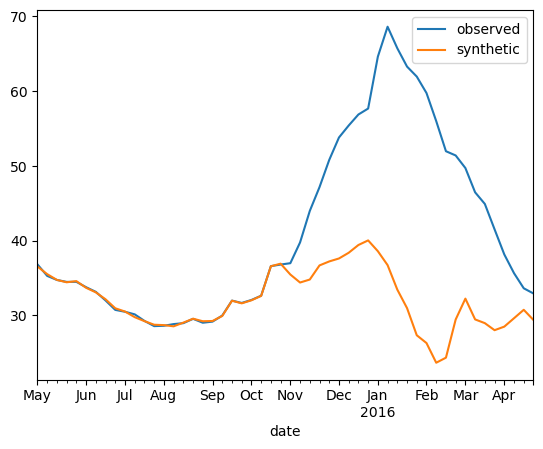

In [7]:
scm_result["synthetic"][['observed','synthetic']].plot()

<Axes: xlabel='date'>

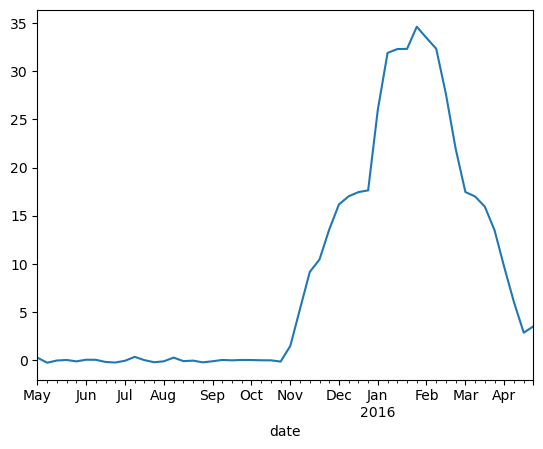

In [8]:
scm_result["synthetic"]['effect'].plot()

In [9]:
mlscm_result=nm.mlscm(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",donors=donor_pool,
                      cutoff_date='2015-10-23',model_config={"time_budget": 10, "metric": "r2", "estimator_list": ["lgbm"], "task": "regression"})


/var/folders/8s/rbx7tx_j2q3d709qdjj7xnjc0000gp/T/ipykernel_87178/1674171111.py:1: ExperimentalWarning: mlscm() is experimental and lacks the causal guarantees of classic SCM. Prefer scm(), scm_abadie(), or scm_mcnnm() for inferential conclusions. See mlscm docstring Notes for details.
  mlscm_result=nm.mlscm(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",donors=donor_pool,


<Axes: xlabel='date'>

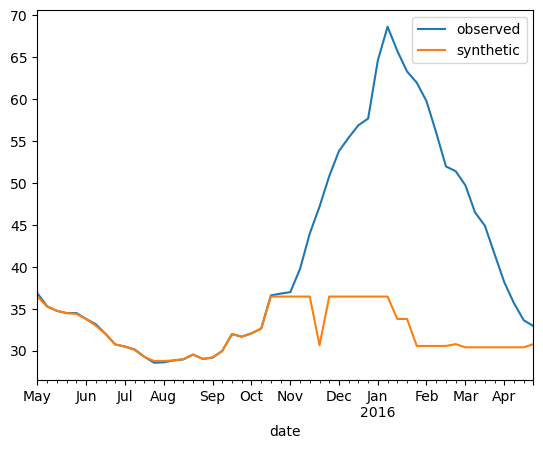

In [10]:
mlscm_result[['observed','synthetic']].plot()

<Axes: xlabel='date'>

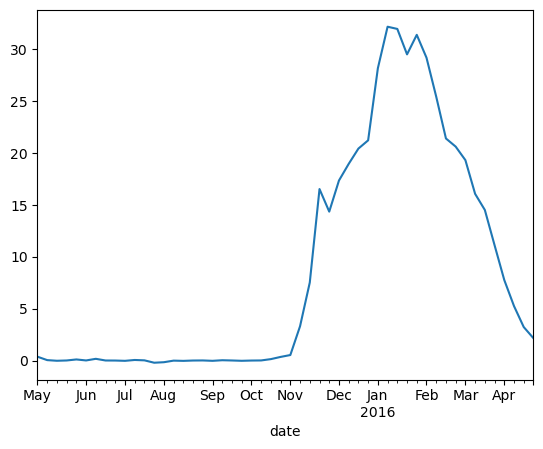

In [11]:
mlscm_result['effect'].plot()

In [12]:
mlscm_result_lgb=nm.mlscm(df,date_col="date",outcome_col='SO2wn',unit_col='ID',
                        treated_unit="2+26 cities",donors=donor_pool,cutoff_date='2015-10-23',backend='lightgbm',model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 80, "early_stopping_rounds": 10})


/var/folders/8s/rbx7tx_j2q3d709qdjj7xnjc0000gp/T/ipykernel_87178/1472957729.py:1: ExperimentalWarning: mlscm() is experimental and lacks the causal guarantees of classic SCM. Prefer scm(), scm_abadie(), or scm_mcnnm() for inferential conclusions. See mlscm docstring Notes for details.
  mlscm_result_lgb=nm.mlscm(df,date_col="date",outcome_col='SO2wn',unit_col='ID',


<Axes: xlabel='date'>

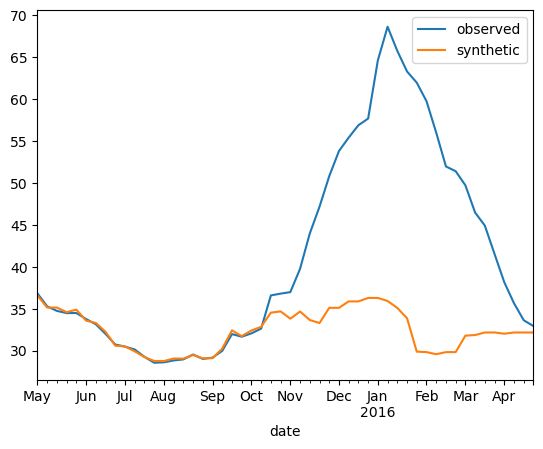

In [13]:
mlscm_result_lgb[['observed','synthetic']].plot()

<Axes: xlabel='date'>

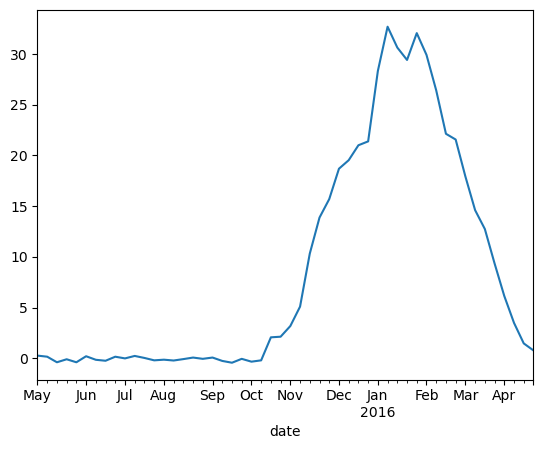

In [14]:
mlscm_result_lgb['effect'].plot()

# Placebo test

In [15]:
# 1) Run placebo-in-space (you already have this)
out = nm.placebo_in_space(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",
                          donors=donor_pool,cutoff_date='2015-10-23')

# 2) Build 95% bands from the placebo distribution (quantile method)
bands = nm.effect_bands_space(out, level=0.95, method="quantile")



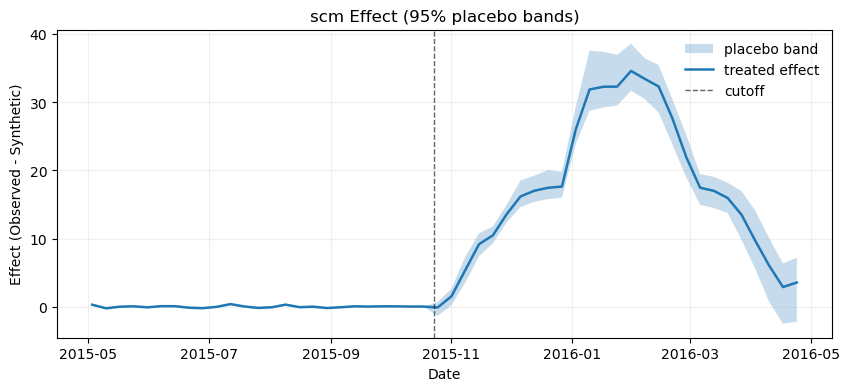

In [16]:
# 3) Plot
nm.plot_effect_with_bands(bands, cutoff_date="2015-10-23", title="scm Effect (95% placebo bands)")
plt.show()

# Uncertainty

In [17]:
out1 = nm.uncertainty_bands(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",donors=donor_pool,
                            cutoff_date='2015-10-23', method = "jackknife")

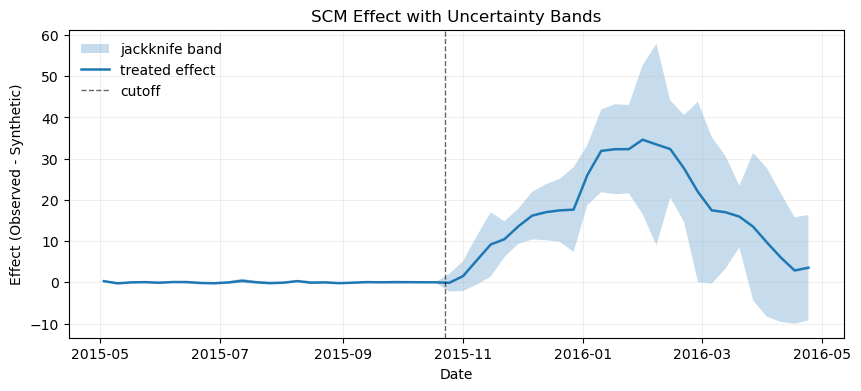

In [18]:
nm.plot_uncertainty_bands(out1, cutoff_date="2015-10-23")
plt.show()

In [19]:
out2 = nm.uncertainty_bands(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",donors=donor_pool,
                            cutoff_date='2015-10-23', method = "bootstrap")

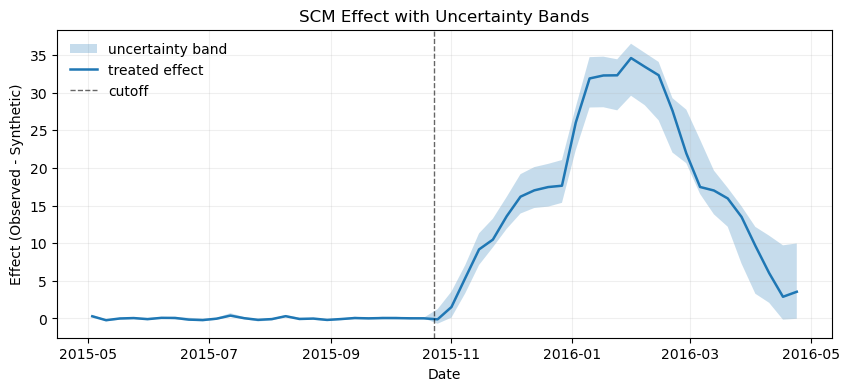

In [20]:
nm.plot_uncertainty_bands(out2, cutoff_date="2015-10-23")
plt.show()

# Placebo test_AutoML based scm

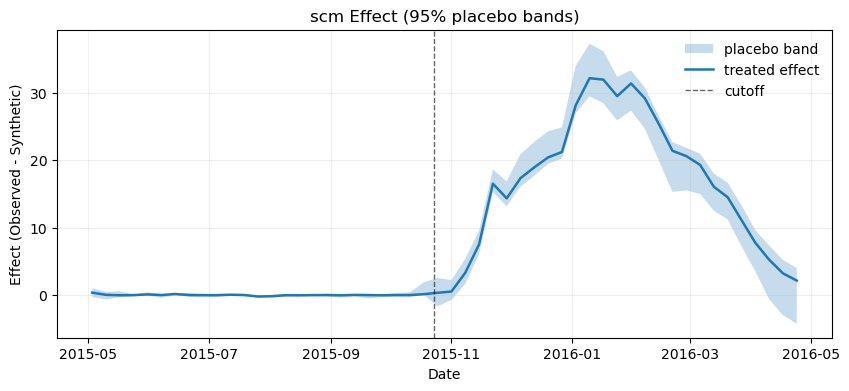

In [21]:
# 1) Run placebo-in-space
out = nm.placebo_in_space(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",
                          donors=donor_pool,cutoff_date='2015-10-23',scm_backend='mlscm',model_config={"time_budget": 10, "metric": "r2", "estimator_list": ["lgbm"], "task": "regression"})

# 2) Build 95% bands from the placebo distribution (quantile method)
bands = nm.effect_bands_space(out, level=0.95, method="quantile")

# 3) Plot
nm.plot_effect_with_bands(bands, cutoff_date="2015-10-23", title="scm Effect (95% placebo bands)")
plt.show()

In [22]:
out = nm.placebo_in_space(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",
                          donors=donor_pool,cutoff_date='2015-10-23',scm_backend='mlscm',backend='lightgbm',
                          verbose=False,model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 80, "early_stopping_rounds": 10})

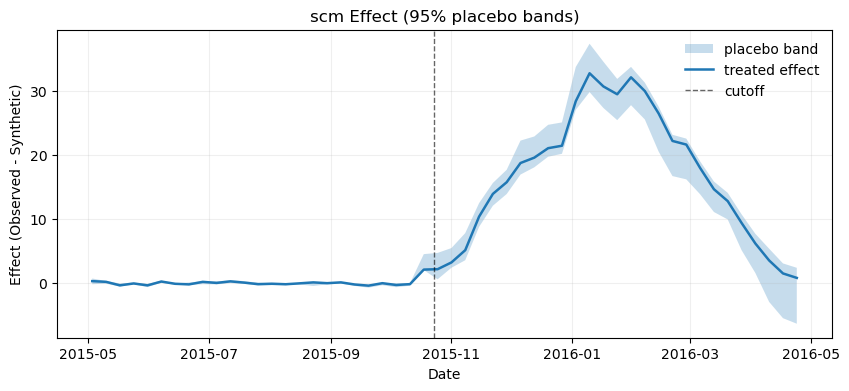

In [23]:
# 2) Build 95% bands from the placebo distribution (quantile method)
bands = nm.effect_bands_space(out, level=0.95, method="quantile")

# 3) Plot
nm.plot_effect_with_bands(bands, cutoff_date="2015-10-23", title="scm Effect (95% placebo bands)")
plt.show()

# Uncertainty_AutoML based scm

In [24]:
out1 = nm.uncertainty_bands(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",donors=donor_pool,
                            cutoff_date='2015-10-23', scm_backend='mlscm',method = "jackknife",model_config={"time_budget": 10, "metric": "r2", "estimator_list": ["lgbm"], "task": "regression"})

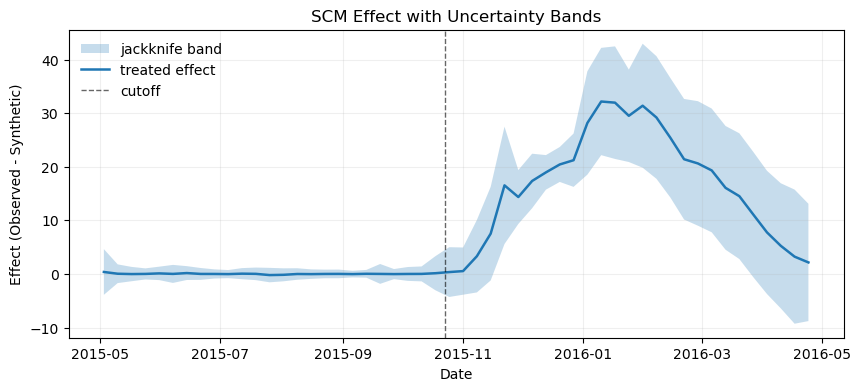

In [25]:
nm.plot_uncertainty_bands(out1, cutoff_date="2015-10-23")
plt.show()

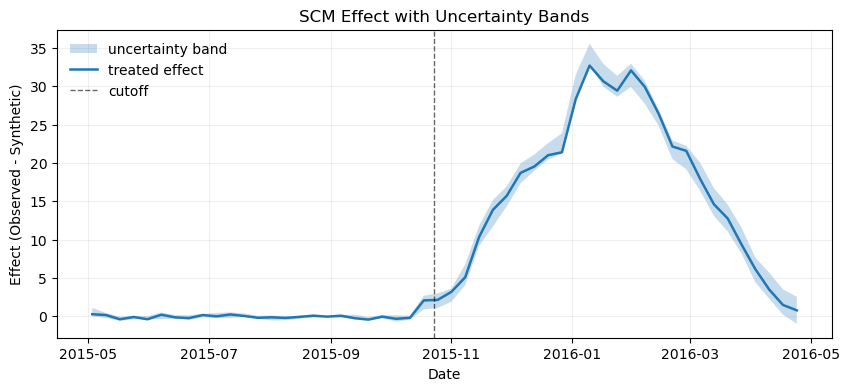

In [26]:
out1 = nm.uncertainty_bands(df,date_col="date",outcome_col='SO2wn',unit_col='ID',treated_unit="2+26 cities",donors=donor_pool,
                            cutoff_date='2015-10-23', scm_backend='mlscm',backend='lightgbm',method = "bootstrap",B=30,model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 80, "early_stopping_rounds": 10})
nm.plot_uncertainty_bands(out1, cutoff_date="2015-10-23")
plt.show()

In [27]:
scm_all=nm.scm_all(df,date_col="date",outcome_col='SO2wn',unit_col='ID',donors=donor_pool,cutoff_date='2015-10-23')

In [28]:
scm_all

,date,observed,synthetic,effect,ID
0,2015-05-03,36.822724,36.537563,0.285161,2+26 cities
1,2015-05-10,35.284317,35.519014,-0.234697,2+26 cities
2,2015-05-17,34.742172,34.747215,-0.005043,2+26 cities
3,2015-05-24,34.482513,34.431788,0.050725,2+26 cities
4,2015-05-31,34.490734,34.585291,-0.094557,2+26 cities
...,...,...,...,...,...
1971,2016-03-27,9.927490,7.499944,2.427546,Zhuhai
1972,2016-04-03,9.500385,7.112385,2.388000,Zhuhai
1973,2016-04-10,8.597066,7.236877,1.360190,Zhuhai
1974,2016-04-17,8.593793,7.401549,1.192244,Zhuhai


# Batch Run

In [29]:
mlscm_all=nm.scm_all(df,date_col="date",outcome_col='SO2wn',unit_col='ID',donors=donor_pool,cutoff_date='2015-10-23',scm_backend='mlscm',model_config={"time_budget": 10, "metric": "r2", "estimator_list": ["lgbm"], "task": "regression"})

In [30]:
mlscm_all

,date,observed,synthetic,effect,ID
0,2015-05-03,36.822724,36.467828,0.354896,2+26 cities
1,2015-05-10,35.284317,35.341285,-0.056968,2+26 cities
2,2015-05-17,34.742172,35.046863,-0.304691,2+26 cities
3,2015-05-24,34.482513,34.490841,-0.008328,2+26 cities
4,2015-05-31,34.490734,34.490841,-0.000107,2+26 cities
...,...,...,...,...,...
1971,2016-03-27,9.927490,8.548103,1.379387,Zhuhai
1972,2016-04-03,9.500385,8.548103,0.952282,Zhuhai
1973,2016-04-10,8.597066,8.548103,0.048963,Zhuhai
1974,2016-04-17,8.593793,8.528259,0.065534,Zhuhai


In [31]:
mlscm_all_lgb=nm.scm_all(df,date_col="date",outcome_col='SO2wn',unit_col='ID',donors=donor_pool,cutoff_date='2015-10-23',scm_backend='mlscm',backend='lightgbm',model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 80, "early_stopping_rounds": 10})

In [32]:
mlscm_all_lgb

,date,observed,synthetic,effect,ID
0,2015-05-03,36.822724,36.568890,0.253834,2+26 cities
1,2015-05-10,35.284317,35.138011,0.146306,2+26 cities
2,2015-05-17,34.742172,35.145018,-0.402846,2+26 cities
3,2015-05-24,34.482513,34.589388,-0.106874,2+26 cities
4,2015-05-31,34.490734,34.894398,-0.403664,2+26 cities
...,...,...,...,...,...
1971,2016-03-27,9.927490,8.632479,1.295010,Zhuhai
1972,2016-04-03,9.500385,8.835811,0.664574,Zhuhai
1973,2016-04-10,8.597066,8.632479,-0.035413,Zhuhai
1974,2016-04-17,8.593793,8.632479,-0.038687,Zhuhai
